# General Task Performance 

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import (
    LLM_MODELS,
    ACS_TASKS,
    TABLESHIFT_TASKS,
    BASELINES,
    FIGURES_ROOT_DIR,
    RESULTS_CSV_SAME_PROMPT,
)

from monoculture.analysis.utils import (
    key_to_model,
    model_to_key,
    prettify_model_name,
    get_size,
    is_instruction_tuned,
    load_model_outputs_same_prompt,
    get_metric,
    load_results_overview,
    add_evals_to_df,
    load_data_if_needed,
    filter_results,
    filter_models_better_const,
    filter_top_models_by_eps,
    df_to_dict,
)
from monoculture.baseline.utils import load_baselines

from monoculture.analysis.plotting import (
    plot_accuracies,
    plot_label_dist,
    plot_general_performance_task,
)

In [17]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

FIGURES_PAPER_DIR = FIGURES_ROOT_DIR / "paper" / "same-prompt"
TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [ ]:
 select_by='balanced_accuracy' # 'accuracy' #

## Load Task Data

In [29]:
try:
    data_all
except NameError:
    print("'data_all' not yet defined")
    data_all = load_data_if_needed(data=None, tasks=TASKS)
else:
    print("Already defined, update if needed.")
    data_all = load_data_if_needed(data=data_all, tasks=TASKS)

Already defined, update if needed.


## Load Baselines

In [30]:
baseline_scores, baseline_evals = load_baselines(baselines=BASELINES, tasks=TASKS)

baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSIncome/Constant_bench-211220205'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSIncome/LogisticRegression_bench-790429520'.
- GBM: Load predictions from 'results/baselines/model-GBM/GBM_task-ACSIncome/GBM_bench-996001762'.
- XGBoost: Load predictions from 'results/baselines/model-XGBoost/XGBoost_task-ACSIncome/XGBoost_bench-3794332052'.
- NN: Load predictions from 'results/baselines/model-NN/NN_task-ACSIncome/NN_bench-276142988'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/model-Constant/Constant_task-ACSEmployment/Constant_bench-1469218015'.
- LogisticRegression: Load predictions from 'results/baselines/model-LogisticRegression/LogisticRegression_task-ACSEmployment/LogisticRegression_bench-2439278790'.
- GBM: Load predictions from 'results/baselines/model-

,Constant,LogisticRegression,GBM,XGBoost,NN
238351,0,0,0,0,0
2995677,0,0,0,0,0
2360043,0,0,1,1,1
1924596,0,0,0,0,0
2803585,0,0,0,0,0


In [31]:
print(f"{'baseline':20} & " + " & ".join(TASKS) + "\\\\")
for baseline in BASELINES:
    row = f"{baseline:20} & "
    for task in TASKS:
        row += f"\t{baseline_evals[task][baseline]['balanced_accuracy']:.4f} & "
    print(row[:-2] + "\\\\")

baseline             & ACSIncome & ACSEmployment & ACSMobility & ACSTravelTime & ACSPublicCoverage & BRFSS_Diabetes & BRFSS_Blood_Pressure\\
Constant             & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 & 	0.5000 \\
LogisticRegression   & 	0.7116 & 	0.7857 & 	0.5164 & 	0.5235 & 	0.5859 & 	0.5253 & 	0.6423 \\
GBM                  & 	0.7952 & 	0.8329 & 	0.5980 & 	0.6663 & 	0.7114 & 	0.5668 & 	0.6607 \\
XGBoost              & 	0.7995 & 	0.8336 & 	0.6055 & 	0.6859 & 	0.7193 & 	0.5710 & 	0.6612 \\
NN                   & 	0.7740 & 	0.8299 & 	0.5516 & 	0.6076 & 	0.6809 & 	0.5322 & 	0.6519 \\


## Load Predictions

In [32]:
threshold_fitted = True

df_0 = load_results_overview(
    num_shots=0, threshold_fitted=threshold_fitted, same_prompt=True
)
df_0 = df_0[df_0["task"].isin(TASKS)]
df_0 = add_evals_to_df(
    df_0, metrics=["fpr", "fnr", "n_samples", "num_pred_negatives"]
)

df_10 = load_results_overview(
    num_shots=10, threshold_fitted=threshold_fitted, same_prompt=True
)
df_10 = df_10[df_10["task"].isin(TASKS)]
df_10 = add_evals_to_df(
    df_10,
    metrics=["fpr", "fnr", "n_samples", "num_pred_negatives"],
)

In [33]:
try:
    assert set(TASKS).issubset(
        set(df_0["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_0['task'].unique())} "
except AssertionError:
    TASKS = list(df_0["task"].unique())
    logging.warning(f"Reduced TASKS to available tasks: {TASKS}")

In [34]:
predictions_all_0 = load_model_outputs_same_prompt(
    df_0, tasks=TASKS, return_risk_scores=False
)
predictions_all_10 = load_model_outputs_same_prompt(
    df_10, tasks=TASKS, return_risk_scores=False
)

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure
ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


## 0-shot vs 10-shot

In [35]:
{task : predictions_all_10[task].shape for task in TASKS}

{'ACSIncome': (166450, 48),
 'ACSEmployment': (323611, 48),
 'ACSMobility': (62094, 46),
 'ACSTravelTime': (146665, 46),
 'ACSPublicCoverage': (113829, 44),
 'BRFSS_Diabetes': (144418, 48),
 'BRFSS_Blood_Pressure': (84676, 46)}

ACSIncome
50
Using accuracy for comparison.
Using accuracy for comparison.
ACSEmployment
49
Using accuracy for comparison.
Using accuracy for comparison.
ACSMobility
50
Using accuracy for comparison.
Using accuracy for comparison.
ACSTravelTime
50
Using accuracy for comparison.
Using accuracy for comparison.
ACSPublicCoverage
50
Using accuracy for comparison.
Using accuracy for comparison.
BRFSS_Blood_Pressure
50
Using accuracy for comparison.
Using accuracy for comparison.
performance-accuracy-0-vs-10_tresh_fitted


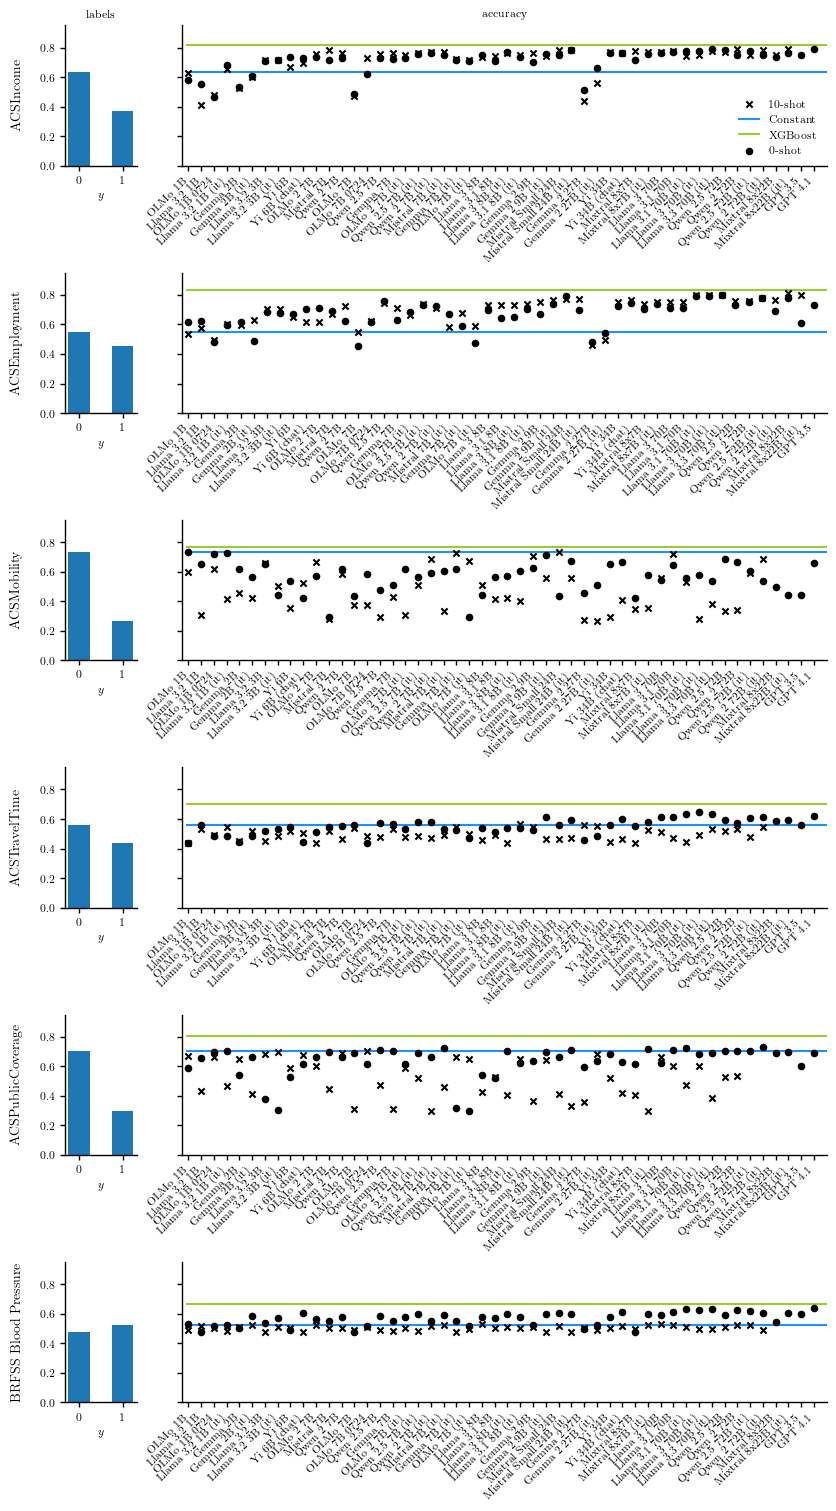

In [36]:
tasks_to_plot = [task for task in TASKS if task != "BRFSS_Diabetes"]

fig_width = 1.5* plt.rcParams['figure.figsize'][0]
fig_height = 5 *  plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
        nrows=len(tasks_to_plot),
        ncols=2,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9]},
        sharey="row",
    )

label_rotation = 45
ha = 'right'

for i, task in enumerate(tasks_to_plot):
    print(task)

    if len(axs[i]) == 3:
        ax_label, ax_accuracy, ax_frac_neg = axs[i]
    else:
        ax_label, ax_accuracy = axs[i]
    mask_0 = (df_0["task"] == task) & (
        df_0["model"].isin(predictions_all_0[task].columns)
    )
    mask_10 = (df_10["task"] == task) & (
        df_10["model"].isin(predictions_all_10[task].columns)
    )

    # task as row label on the left
    ax_label.annotate(
        task.replace("_", " "),
        xy=(0, 0.5),
        xytext=(-ax_label.yaxis.labelpad - 5, 0),
        xycoords=ax_label.yaxis.label,
        textcoords="offset points",
        size="medium",
        ha="right",
        va="center",
        rotation=90,
    )

    y_true = data_all[task][1]
    num_models = df_0[mask_0].shape[0]
    print(num_models)
    # # 10-shot
    models_to_highlight_10 = filter_models_better_const(
        df_10[df_10["task"] == task], y_true=y_true, acc=select_by
    )
    # models_to_highlight_10 = filter_top_models_by_eps(df_10[df_10['task']==task])
    models_to_highlight_10 = predictions_all_10[task].columns.to_list()
    acc_dict = df_to_dict(df_10[mask_10][["model", select_by]])
    plot_accuracies(
        ax_accuracy,
        evals=acc_dict,
        baseline_accs=None,
        models_above_baseline=models_to_highlight_10,
        hline_xmin=-0.2,
        hline_xmax=num_models + 0.1,
        marker="x",
        scatter_label="10-shot",
        label_rotation = label_rotation,
        ha = ha
    )
    # 0-shot
    models_to_highlight_0 = filter_models_better_const(
        df_0[df_0["task"] == task], y_true=y_true, acc=select_by
    )
    # models_to_highlight_0 = filter_top_models_by_eps(df_0[df_0['task']==task])
    models_to_highlight_0 = predictions_all_0[task].columns.to_list()
    plot_general_performance_task(
        axs[i],
        df=df_0[mask_0],
        baseline_evals=baseline_evals[task],
        ytrue=y_true,
        models_to_highlight=models_to_highlight_0,
        marker="o",
        scatter_label="0-shot",
        acc=select_by,
        label_rotation = label_rotation,
        ha = ha
    )

axs[0, 1].legend(loc="lower right")
# set column titles
titles = ["labels", select_by.replace('_', ' '), 'fraction negative predicted']
for c in range(len(axs[i])):
    axs[0,c].set_title(titles[c])

file_name = f"performance-{select_by.replace('_', '-')}-0-vs-10" + ("_tresh_fitted" if threshold_fitted == 1 else "") #+ '_b'
print(file_name)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))

plt.show()

In [37]:
means_0 = []
means_10 = []
print(acc)
for task in tasks_to_plot:
    print(task)
    mask_0 = (df_0["task"] == task) & (
        df_0["model"].isin(predictions_all_0[task].columns)
    )
    mask_10 = (df_10["task"] == task) & (
        df_10["model"].isin(predictions_all_10[task].columns)
    )
    
    print(f"0-shot mean acc:  {df_0[mask_0][acc].mean():4f}")
    print(f"10-shot mean acc: {df_10[mask_10][acc].mean():4f}")
    means_0.append(df_0[mask_0][acc].mean())
    means_10.append(df_10[mask_10][acc].mean())
np.array(means_0).mean(), np.array(means_10).mean()

balanced_accuracy
ACSIncome
0-shot mean acc:  0.722206
10-shot mean acc: 0.715941
ACSEmployment
0-shot mean acc:  0.675162
10-shot mean acc: 0.698776
ACSMobility
0-shot mean acc:  0.533287
10-shot mean acc: 0.501001
ACSTravelTime
0-shot mean acc:  0.562107
10-shot mean acc: 0.504908
ACSPublicCoverage
0-shot mean acc:  0.569096
10-shot mean acc: 0.504806
BRFSS_Blood_Pressure
0-shot mean acc:  0.569624
10-shot mean acc: 0.504515


(0.6052469407283286, 0.5716576703008188)